# SHMS 训练数据可视化 Notebook

本 Notebook 用于快速检查 `mc-single-arm` 生成训练数据的分布、相关性和二维关系，帮助定位：
- 数据覆盖不足
- 特征偏态/异常
- 标签可观测性弱（例如 `ytar`）

In [31]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot

plt.style.use('default')
SEED = 42
np.random.seed(SEED)

In [32]:
# ===== 路径与列配置 =====
ROOT_FILE = Path(r"C:\Users\Lanto\Desktop\AI_ML R-SIDIS\mc-single-arm\worksim\shms_extended_nosieve.root")
TREE_NAME = 'h10'

INPUT_COLS = ['psxfp', 'psyfp', 'psxpfp', 'psypfp', 'psxtari']
TARGET_COLS = ['psxptari', 'psyptari', 'psztari', 'psdeltai']
OPTIONAL_COLS = ['stop_id', 'snum']

assert ROOT_FILE.exists(), f'ROOT file not found: {ROOT_FILE}'
print('ROOT file:', ROOT_FILE)

ROOT file: C:\Users\Lanto\Desktop\AI_ML R-SIDIS\mc-single-arm\worksim\shms_extended_nosieve.root


In [33]:
# ===== 读取数据 =====
with uproot.open(ROOT_FILE) as f:
    tree = f[TREE_NAME]
    available = set(tree.keys())
    read_cols = [c for c in (INPUT_COLS + TARGET_COLS + OPTIONAL_COLS) if c in available]
    df = tree.arrays(read_cols, library='pd')

print('Rows:', len(df))
print('Columns:', list(df.columns))
df.head()

Rows: 115947
Columns: ['psxfp', 'psyfp', 'psxpfp', 'psypfp', 'psxtari', 'psxptari', 'psyptari', 'psztari', 'psdeltai', 'stop_id']


,psxfp,psyfp,psxpfp,psypfp,psxtari,psxptari,psyptari,psztari,psdeltai,stop_id
0,14.819504,5.316219,0.032367,0.006006,-0.312204,-0.004471,0.010300,11.137589,9.857979,0.0
1,-2.465010,-9.841401,-0.010240,-0.010953,0.035921,0.007805,-0.011315,-18.455000,-1.201415,0.0
2,32.989342,-19.766640,0.066558,-0.007466,-0.269537,-0.002776,-0.012953,-3.206803,25.524383,0.0
3,15.725097,1.503310,0.071937,0.001973,0.652454,-0.040384,0.008837,10.493195,18.776357,0.0
4,22.149036,1.944555,0.063763,0.004833,0.446667,-0.020093,0.010738,12.029745,20.391124,0.0


In [34]:
# ===== 可选：仅保留 stop_id == 0 的成功事件（若该列存在）=====
if 'stop_id' in df.columns:
    before = len(df)
    df_ok = df[df['stop_id'] == 0].copy()
    print(f'stop_id available: keep {len(df_ok)}/{before} rows ({len(df_ok)/max(before,1):.2%})')
else:
    df_ok = df.copy()
    print('stop_id not found, use all rows.')

if len(df_ok) == 0:
    raise RuntimeError('No valid rows to visualize (df_ok is empty).')

stop_id available: keep 115947/115947 rows (100.00%)


In [35]:
# ===== 基本统计 =====
cols = [c for c in INPUT_COLS + TARGET_COLS if c in df_ok.columns]
summary = df_ok[cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T
summary[['mean', 'std', 'min', '1%', '5%', '50%', '95%', '99%', 'max']]

,mean,std,min,1%,5%,50%,95%,99%,max
psxfp,3.839971,19.758002,-37.166138,-35.450327,-30.468771,5.833014,32.320343,35.877948,37.827595
psyfp,-1.774286,12.627630,-37.773102,-30.340091,-22.424698,-1.930638,19.670156,28.568799,37.883934
psxpfp,0.012521,0.045108,-0.086818,-0.073816,-0.062236,0.014997,0.081124,0.092775,0.103736
psypfp,-0.001977,0.013872,-0.051120,-0.036982,-0.024454,-0.002174,0.021903,0.035728,0.049910
psxtari,0.003937,0.426511,-1.615390,-1.010862,-0.692304,0.004262,0.694885,1.002415,1.616741
psxptari,-0.006227,0.022546,-0.054292,-0.046119,-0.039914,-0.007870,0.032724,0.042764,0.052796
psyptari,0.000327,0.019522,-0.049794,-0.038336,-0.030311,-0.000635,0.033716,0.043664,0.054085
psztari,-2.323077,14.654623,-29.999516,-29.245140,-26.326876,-1.878399,20.653606,25.496789,29.971937
psdeltai,4.829338,14.174966,-24.213932,-19.994774,-16.072411,3.819808,28.936292,34.320514,41.022245


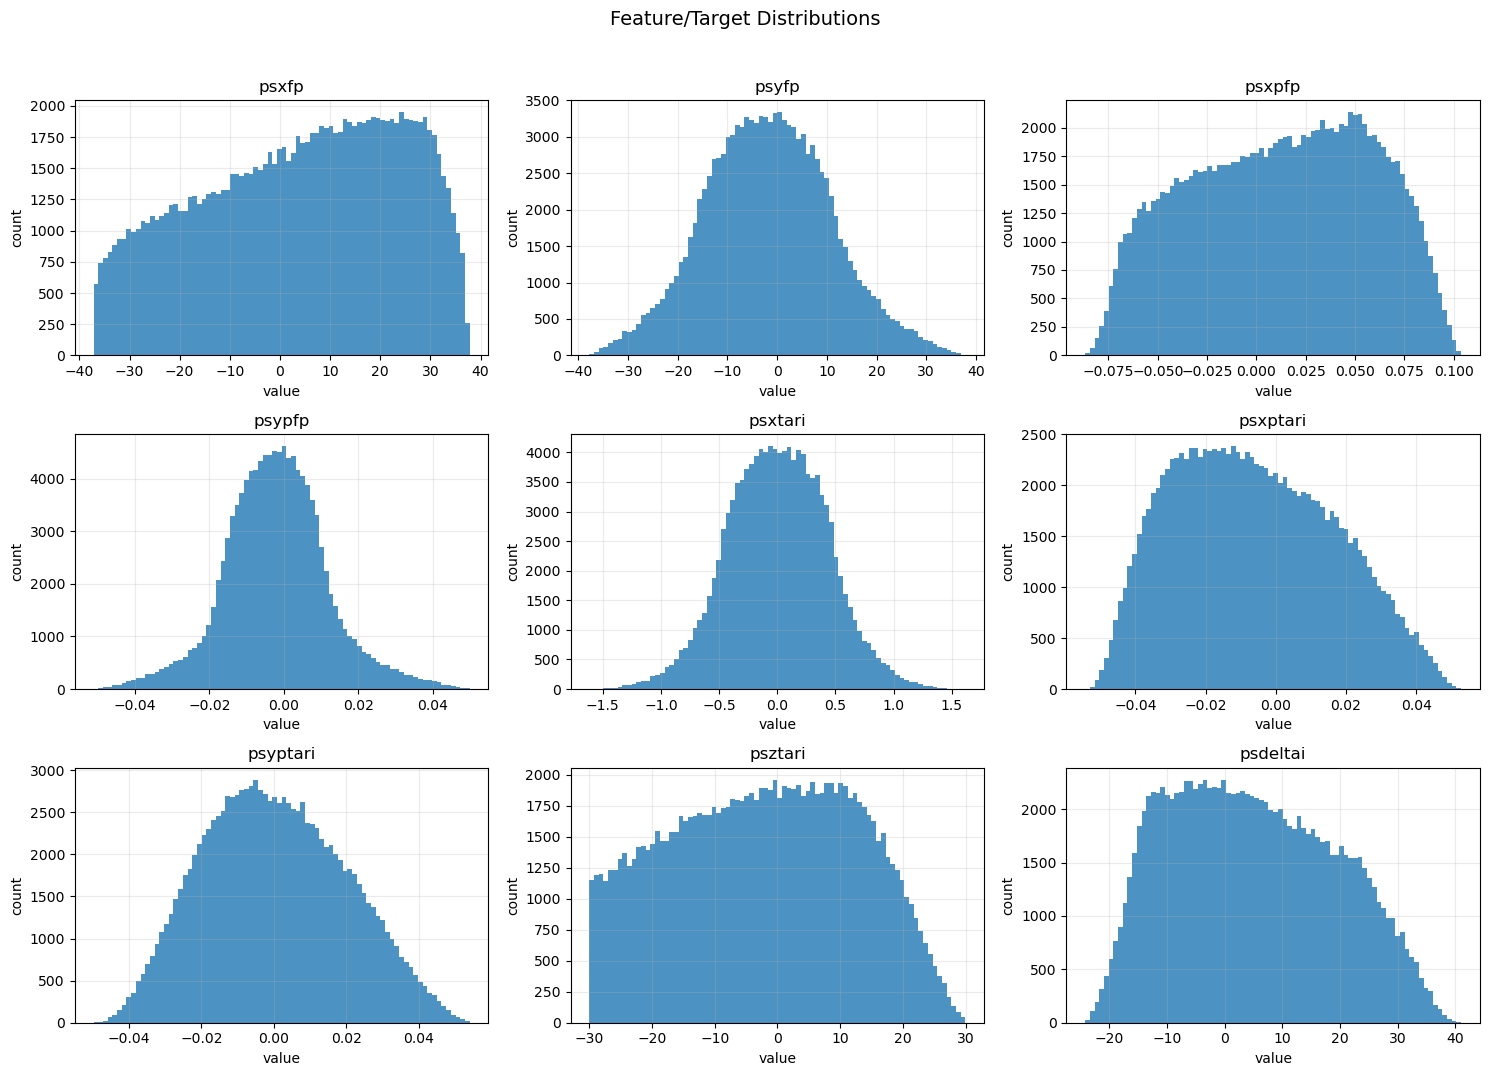

In [36]:
# ===== 1D 分布图（输入 + 标签）=====
n = len(cols)
ncol = 3
nrow = int(np.ceil(n / ncol))

fig, axes = plt.subplots(nrow, ncol, figsize=(5*ncol, 3.5*nrow))
axes = np.array(axes).reshape(-1)

for i, c in enumerate(cols):
    ax = axes[i]
    x = df_ok[c].to_numpy()
    ax.hist(x, bins=80, alpha=0.8)
    ax.set_title(c)
    ax.set_xlabel('value')
    ax.set_ylabel('count')
    ax.grid(alpha=0.25)

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Feature/Target Distributions', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

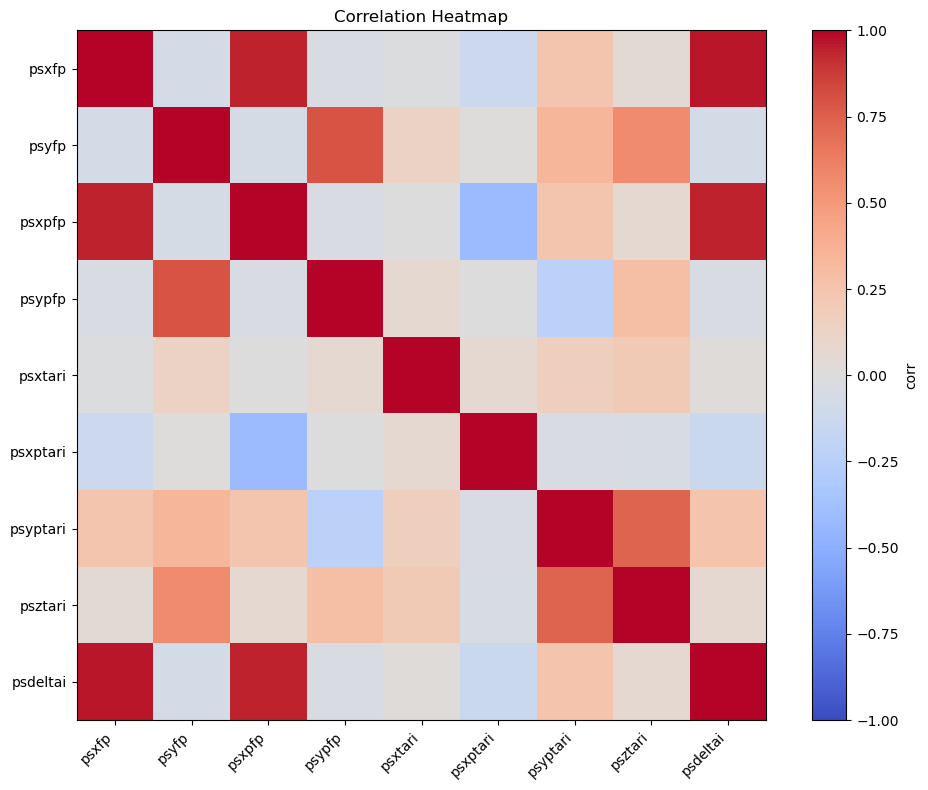

In [37]:
# ===== 相关性热图 =====
corr = df_ok[cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(np.arange(len(cols)))
ax.set_yticks(np.arange(len(cols)))
ax.set_xticklabels(cols, rotation=45, ha='right')
ax.set_yticklabels(cols)
ax.set_title('Correlation Heatmap')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('corr')
plt.tight_layout()
plt.show()

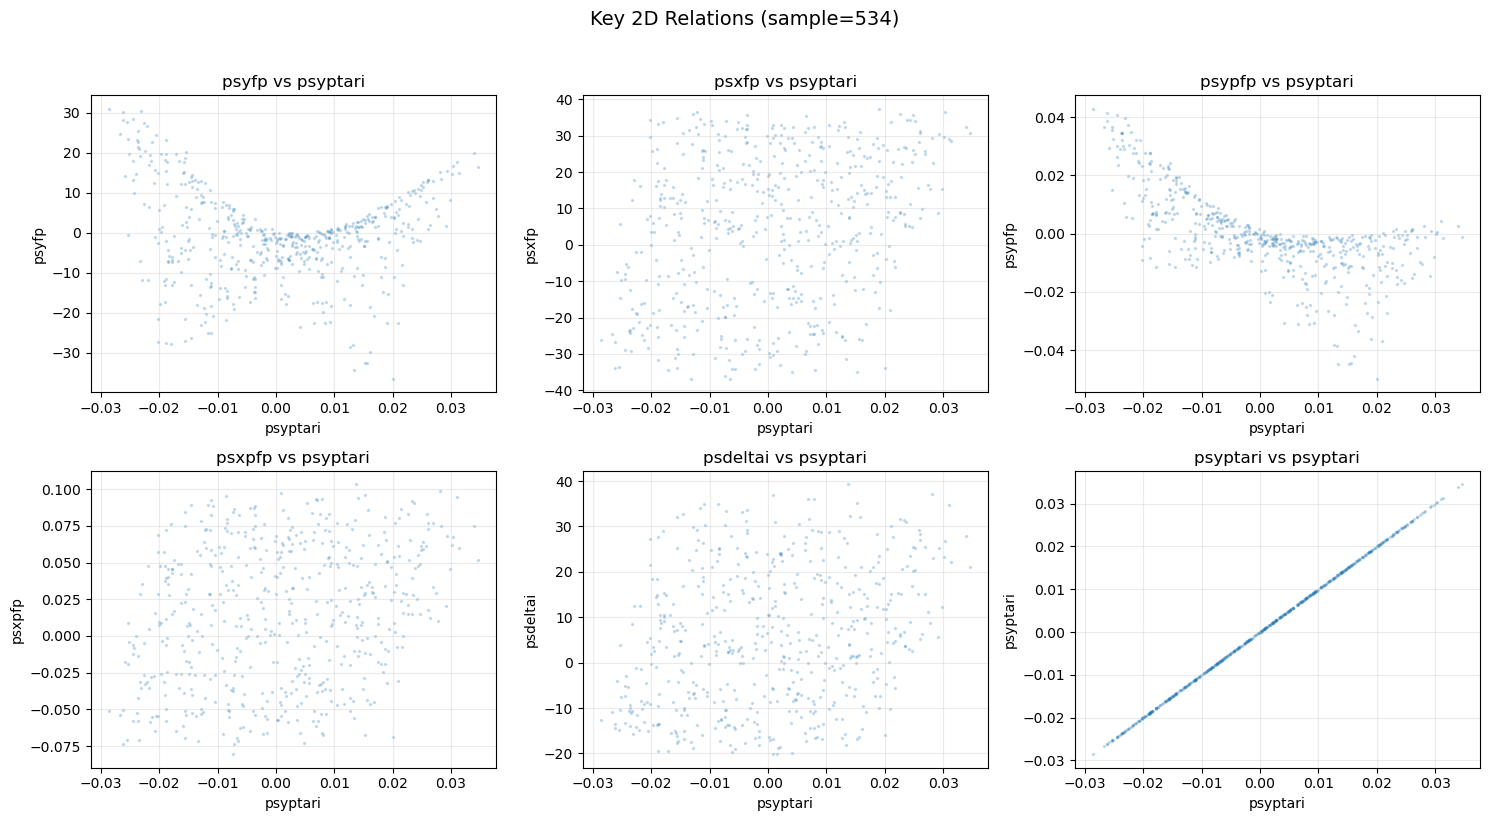

In [43]:
# ===== 关键二维关系散点（随机抽样避免过密）=====
pairs = [
    ('psyptari', 'psyfp'),
    ('psyptari',  'psxfp'),
    ('psyptari','psypfp'),
    ('psyptari', 'psxpfp'),
    ('psyptari', 'psdeltai'),
    ('psyptari',  'psyptari'),
]



# 最多抽样 50k 点用于散点图
cond = abs(df_ok.psztari) < 0.1
df_selected = df_ok[cond]
sample_n = min(50000, len(df_selected))
sample_df = df_selected.sample(n=sample_n, random_state=SEED) if len(df_selected) > sample_n else df_selected

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for i, (xcol, ycol) in enumerate(pairs):
    ax = axes[i]
    if xcol in sample_df.columns and ycol in sample_df.columns:
        ax.scatter(sample_df[xcol], sample_df[ycol], s=2, alpha=0.2)
        ax.set_xlabel(xcol)
        ax.set_ylabel(ycol)
        ax.set_title(f'{ycol} vs {xcol}')
        ax.grid(alpha=0.25)
    else:
        ax.text(0.5, 0.5, f'Missing: {xcol} or {ycol}', ha='center', va='center')
        ax.axis('off')

plt.suptitle(f'Key 2D Relations (sample={len(sample_df)})', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

In [39]:
# ===== 标签可观测性快速提示：输入对标签的线性相关排序 =====
inputs = [c for c in INPUT_COLS if c in df_ok.columns]
targets = [c for c in TARGET_COLS if c in df_ok.columns]

for t in targets:
    corr_abs = df_ok[inputs + [t]].corr(numeric_only=True)[t].drop(t).abs().sort_values(ascending=False)
    print(f'\nTarget: {t}')
    print(corr_abs.to_string())


Target: psxptari
psxpfp     0.418196
psxfp      0.118192
psxtari    0.068254
psypfp     0.001923
psyfp      0.001348

Target: psyptari
psyfp      0.336438
psxfp      0.236916
psxpfp     0.235017
psypfp     0.227746
psxtari    0.159230

Target: psztari
psyfp      0.562845
psypfp     0.282865
psxtari    0.201891
psxpfp     0.067886
psxfp      0.053512

Target: psdeltai
psxfp      0.967049
psxpfp     0.943016
psyfp      0.063756
psypfp     0.038857
psxtari    0.017995
